## ARIMA
    

In [ ]:
# ── Colab / Local setup ──────────────────────────────────────────────────
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # 1. Clone the repo
    import subprocess
    subprocess.run(["git", "clone", "https://github.com/DaTking4/ml-final-project-walmart-recruiting.git"], check=True)
    %cd ml-final-project-walmart-recruiting

    # 2. Install dependencies
    %pip install -q -r requirements.txt

    # 3. Inject Colab secrets as environment variables
    import os
    from google.colab import userdata
    os.environ["DAGSHUB_USER_TOKEN"] = userdata.get("DAGSHUB_TOKEN")
    os.environ["WANDB_API_KEY"]    = userdata.get("WANDB_API_KEY")
    os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

    # 4. Download competition data
    %pip install -q kaggle
    import os
    os.makedirs("data", exist_ok=True)
    !kaggle competitions download -c walmart-recruiting-store-sales-forecasting -p data/ --quiet
    !unzip -q -o data/walmart-recruiting-store-sales-forecasting.zip -d data/

print("Running in:", "Google Colab" if IN_COLAB else "Local environment")


### 1. Setup and Imports
    

In [1]:
import os
import sys
import importlib
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))

repo_root = Path.cwd()
while repo_root != repo_root.parent:
    if (repo_root / "src").exists():
        sys.path.insert(0, str(repo_root))
        break
    repo_root = repo_root.parent
else:
    raise FileNotFoundError("Could not locate the repository root containing 'src'.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import mlflow
import mlflow.pyfunc
from mlflow.models import infer_signature

import wandb

import src.mlflow_setup as mlflow_setup
importlib.reload(mlflow_setup)
init_tracking = mlflow_setup.init_tracking
from src.data_loading import load_merged
from src.transforms import apply_shared_features
from src.validation import time_based_split
from src.pipeline.arima_pipeline import ARIMAForecastPipeline
from src.arima_utils import (
    arima_order,
    evaluate_arima_config,
    fit_arima_models,
    forecast_one_series,
    to_arima_long,
)

init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

print("Current MLflow URI:", mlflow.get_tracking_uri())

if mlflow.active_run() is not None:
    mlflow.end_run()

BLUE = "#7196C7"
GREEN = "#5E9D74"
RED = "#7E3838"
PURPLE = "#705588"

print("Setup complete.")


Accessing as lchit22

Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Current MLflow URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow
Setup complete.


### 2. Configuration
    

In [2]:
init_tracking()
assert "dagshub.com" in mlflow.get_tracking_uri(), mlflow.get_tracking_uri()

EXPERIMENT_NAME = "ARIMA_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

WANDB_ENTITY = "dkhak22-free-university-of-tbilisi-"
WANDB_PROJECT = "walmart-sales-forecasting"

CONFIG = {
    "input_size": 52,
    "horizon": 26,
    "random_seed": 42,
    "min_train_points": 52,
    "maxiter": 80,
}

FREQ = "W-FRI"
MODEL_COL = "ARIMA"

CONFIG


Initialized MLflow to track repo "dkhak22/ml-final-project-store-sales-forecasting"

Repository dkhak22/ml-final-project-store-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow


{'input_size': 52,
 'horizon': 26,
 'random_seed': 42,
 'min_train_points': 52,
 'maxiter': 80}

### 3. Load Data
    

In [3]:
train_df, test_df = load_merged()

print(f"train_df: {train_df.shape}")
print(f"test_df:  {test_df.shape}")

CONFIG["horizon"] = test_df["Date"].nunique()

train_df.head()


train_df: (421570, 16)
test_df:  (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


### 4. Shared Preprocessing and Feature Engineering
    

In [4]:
train_prepared = apply_shared_features(train_df)

print(f"train_prepared: {train_prepared.shape}")
train_prepared.head()


train_prepared: (421570, 23)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Size,Type_A,Type_B,Type_C,Year,Month,WeekOfYear,DaysSinceLastHoliday,DaysToNextHoliday
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,5,inf,7.0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,6,0.0,0.0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,7,7.0,203.0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,2,8,14.0,196.0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,8.106,151315,True,False,False,2010,3,9,21.0,189.0


### 5. Feature Selection

In [5]:
ARIMA_FEATURE_DECISION = {
    "feature_set": "target_history_only",
    "uses_exogenous_features": False,
    "used_model_columns": "unique_id, ds, y",
    "reason": (
        "ARIMA is used as a univariate history-based baseline. It uses only "
        "historical Weekly_Sales for each Store-Dept series."
    ),
}

ARIMA_FEATURE_DECISION


{'feature_set': 'target_history_only',
 'uses_exogenous_features': False,
 'used_model_columns': 'unique_id, ds, y',
 'reason': 'ARIMA is used as a univariate history-based baseline. It uses only historical Weekly_Sales for each Store-Dept series.'}

### 6. Time-Series and Window Setup
    

In [6]:
train_part, valid_part = time_based_split(
    train_prepared,
    valid_weeks=CONFIG["horizon"],
)

print(f"Train part: {train_part['Date'].min().date()} -> {train_part['Date'].max().date()}")
print(f"Valid part: {valid_part['Date'].min().date()} -> {valid_part['Date'].max().date()}")
print(f"\nInput size: {CONFIG['input_size']} weeks")
print(f"Forecast horizon: {CONFIG['horizon']} weeks")

long_df = to_arima_long(train_prepared)
train_long = to_arima_long(train_part)
valid_long = to_arima_long(valid_part)

series_lengths = long_df.groupby("unique_id").size()
train_lengths = train_long.groupby("unique_id").size()
valid_lengths = valid_long.groupby("unique_id").size()

ARIMA_SERIES_LENGTH = int(series_lengths.max())
arima_ids = series_lengths[series_lengths == ARIMA_SERIES_LENGTH].index
arima_ids = arima_ids.intersection(train_lengths[train_lengths >= CONFIG["min_train_points"]].index)
arima_ids = arima_ids.intersection(valid_lengths[valid_lengths == CONFIG["horizon"]].index)

arima_df = long_df[long_df["unique_id"].isin(arima_ids)].copy()
arima_train_long = train_long[train_long["unique_id"].isin(arima_ids)].copy()
arima_valid_long = valid_long[valid_long["unique_id"].isin(arima_ids)].copy()

print("\nSeries length summary:")
display(series_lengths.describe())
print("\nARIMA training/evaluation frame:")
print(f"Using {len(arima_ids)} complete-history Store-Dept series")
print(f"Dropping {long_df['unique_id'].nunique() - len(arima_ids)} short/ragged series")
print(f"Rows used by ARIMA: {arima_df.shape[0]:,}")

holiday_lookup = train_prepared.assign(
    unique_id=train_prepared["Store"].astype(str) + "_" + train_prepared["Dept"].astype(str),
    ds=train_prepared["Date"],
)[["unique_id", "ds", "IsHoliday"]].drop_duplicates()
holiday_lookup["IsHoliday"] = holiday_lookup["IsHoliday"].fillna(False).astype(bool)

train_by_id = {
    uid: group.sort_values("ds").set_index("ds")["y"].astype(float).asfreq("W-FRI")
    for uid, group in arima_train_long.groupby("unique_id")
}
valid_by_id = {
    uid: group.sort_values("ds")[["unique_id", "ds", "y"]].copy()
    for uid, group in arima_valid_long.groupby("unique_id")
}

print("Prepared grouped ARIMA inputs.")


def fit_gap_pct(train_wmae, val_wmae):
    if pd.isna(train_wmae) or train_wmae == 0:
        return np.nan
    return ((val_wmae - train_wmae) / train_wmae) * 100


def classify_fit_status(train_wmae, val_wmae):
    gap = fit_gap_pct(train_wmae, val_wmae)
    if pd.isna(gap):
        return "unknown"
    if gap > 25:
        return "overfit"
    if gap < -10:
        return "underfit"
    return "good"

Train part: 2010-02-05 -> 2012-01-27
Valid part: 2012-02-03 -> 2012-10-26

Input size: 52 weeks
Forecast horizon: 39 weeks

Series length summary:


count    3331.000000
mean      126.559592
std        40.212763
min         1.000000
25%       143.000000
50%       143.000000
75%       143.000000
max       143.000000
dtype: float64


ARIMA training/evaluation frame:
Using 2660 complete-history Store-Dept series
Dropping 671 short/ragged series
Rows used by ARIMA: 380,380
Prepared grouped ARIMA inputs.


### 7. Forward and Backward Check
    

In [7]:
sanity_config = {
    "label": "sanity_arima_110",
    "regime": "sanity",
    "p": 1,
    "d": 1,
    "q": 0,
    "trend": "n",
    "enforce_stationarity": False,
    "enforce_invertibility": False,
    "concentrate_scale": False,
    "maxiter": 20,
}

sample_id = arima_ids[0]
y_train = train_by_id[sample_id]
valid_group = valid_by_id[sample_id]

forecast, failed = forecast_one_series(
    y_train=y_train,
    steps=len(valid_group),
    config=sanity_config,
    min_train_points=CONFIG["min_train_points"],
    fallback_value=float(y_train.iloc[-1]),
)

assert len(forecast) == CONFIG["horizon"]
assert np.isfinite(forecast).all()

print("ARIMA sanity check passed")
print("Used fallback:", failed)
pd.DataFrame({"ds": valid_group["ds"].to_numpy(), "forecast": forecast}).head()


ARIMA sanity check passed
Used fallback: False


,ds,forecast
0,2012-02-03,32569.809637
1,2012-02-10,32569.892351
2,2012-02-17,32569.892992
3,2012-02-24,32569.892997
4,2012-03-02,32569.892997


### 8. Baseline Run
    

In [ ]:
baseline_config = {
    "label": "baseline_arima_110",
    "regime": "baseline",
    "p": 1,
    "d": 1,
    "q": 0,
    "trend": "n",
    "enforce_stationarity": False,
    "enforce_invertibility": False,
    "concentrate_scale": False,
    "maxiter": CONFIG["maxiter"],
}

with mlflow.start_run(run_name="ARIMA_Baseline") as run:
    wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name="ARIMA_Baseline",
        group="ARIMA",
        job_type="baseline",
        tags=["ARIMA", "baseline", "target_history_only"],
        config={**CONFIG, **baseline_config, **ARIMA_FEATURE_DECISION},
        reinit=True,
    )

    try:
        baseline_cv_df, baseline_val_wmae, baseline_failures, baseline_train_wmae = evaluate_arima_config(
            config=baseline_config,
            arima_ids=arima_ids,
            train_by_id=train_by_id,
            valid_by_id=valid_by_id,
            holiday_lookup=holiday_lookup,
            model_col=MODEL_COL,
            min_train_points=CONFIG["min_train_points"],
        )

        gap_pct = fit_gap_pct(baseline_train_wmae, baseline_val_wmae)
        fit_status = classify_fit_status(baseline_train_wmae, baseline_val_wmae)

        print(f"Baseline train WMAE:      {baseline_train_wmae:,.2f}")
        print(f"Baseline validation WMAE: {baseline_val_wmae:,.2f}")
        print(f"Baseline gap:             {gap_pct:,.2f}% ({fit_status})")
        print(f"Baseline fallback/failed series: {baseline_failures:,}")

        mlflow.log_params({**CONFIG, **ARIMA_FEATURE_DECISION})
        mlflow.log_params({
            "label": baseline_config["label"],
            "regime": baseline_config["regime"],
            "p": baseline_config["p"],
            "d": baseline_config["d"],
            "q": baseline_config["q"],
            "order": arima_order(baseline_config),
            "trend": baseline_config["trend"],
            "enforce_stationarity": baseline_config["enforce_stationarity"],
            "enforce_invertibility": baseline_config["enforce_invertibility"],
            "concentrate_scale": baseline_config["concentrate_scale"],
            "maxiter": baseline_config["maxiter"],
            "arima_n_series": len(arima_ids),
            "gradient_logging_applicable": False,
            "gradient_logging_reason": "ARIMA is a statistical model, not a neural backpropagation model.",
        })

        mlflow.log_metric("train_wmae", baseline_train_wmae)
        mlflow.log_metric("val_wmae", baseline_val_wmae)
        mlflow.log_metric("gap_pct", gap_pct)
        mlflow.log_param("fit_status", fit_status)
        mlflow.log_metric("fallback_series", baseline_failures)

        wandb.log({
            "train_wmae": baseline_train_wmae,
            "val_wmae": baseline_val_wmae,
            "gap_pct": gap_pct,
            "fit_status": fit_status,
            "fallback_series": baseline_failures,
        })

        os.makedirs("artifacts", exist_ok=True)

        baseline_arima_dir = Path("artifacts") / "arima_baseline"
        baseline_arima_dir.mkdir(parents=True, exist_ok=True)
        baseline_arima_model_path = baseline_arima_dir / "arima_models.joblib"

        baseline_models, baseline_fit_failures = fit_arima_models(
            full_long_df=arima_train_long,
            ids=arima_ids,
            config=baseline_config,
        )

        joblib.dump(
            {
                "models": baseline_models,
                "config": baseline_config,
                "failed_series": baseline_fit_failures,
            },
            baseline_arima_model_path,
        )

        mlflow.log_artifacts(str(baseline_arima_dir), artifact_path="arima_model")

        baseline_run_id = run.info.run_id

    finally:
        wandb.finish()

### 9. Hyperparameters
    

In [9]:
param_grid = [
    {"label": "underfit_1", "regime": "underfit", "p": 0, "d": 1, "q": 0, "trend": "n", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 40},
    {"label": "underfit_2", "regime": "underfit", "p": 1, "d": 0, "q": 0, "trend": "n", "enforce_stationarity": True, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 40},
    {"label": "underfit_3", "regime": "underfit", "p": 0, "d": 1, "q": 1, "trend": "n", "enforce_stationarity": False, "enforce_invertibility": True, "concentrate_scale": False, "maxiter": 40},
    {"label": "underfit_4", "regime": "underfit", "p": 1, "d": 1, "q": 0, "trend": "n", "enforce_stationarity": True, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 40},
    {"label": "underfit_5", "regime": "underfit", "p": 0, "d": 0, "q": 1, "trend": "n", "enforce_stationarity": False, "enforce_invertibility": True, "concentrate_scale": False, "maxiter": 40},
    {"label": "underfit_6", "regime": "underfit", "p": 1, "d": 1, "q": 1, "trend": "n", "enforce_stationarity": True, "enforce_invertibility": True, "concentrate_scale": False, "maxiter": 40},

    {"label": "balanced_1", "regime": "balanced", "p": 1, "d": 1, "q": 0, "trend": "n", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_2", "regime": "balanced", "p": 0, "d": 1, "q": 1, "trend": "n", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_3", "regime": "balanced", "p": 1, "d": 1, "q": 1, "trend": "n", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_4", "regime": "balanced", "p": 2, "d": 1, "q": 0, "trend": "n", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_5", "regime": "balanced", "p": 0, "d": 1, "q": 2, "trend": "n", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_6", "regime": "balanced", "p": 2, "d": 1, "q": 1, "trend": "n", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_7", "regime": "balanced", "p": 1, "d": 1, "q": 2, "trend": "n", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_8", "regime": "balanced", "p": 2, "d": 1, "q": 2, "trend": "n", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_9", "regime": "balanced", "p": 1, "d": 1, "q": 0, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_10", "regime": "balanced", "p": 0, "d": 1, "q": 1, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_11", "regime": "balanced", "p": 1, "d": 1, "q": 1, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_12", "regime": "balanced", "p": 2, "d": 1, "q": 0, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_13", "regime": "balanced", "p": 0, "d": 1, "q": 2, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_14", "regime": "balanced", "p": 1, "d": 0, "q": 1, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_15", "regime": "balanced", "p": 2, "d": 0, "q": 1, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_16", "regime": "balanced", "p": 1, "d": 0, "q": 2, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 80},
    {"label": "balanced_17", "regime": "balanced", "p": 2, "d": 1, "q": 1, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": True, "maxiter": 120},
    {"label": "balanced_18", "regime": "balanced", "p": 1, "d": 1, "q": 2, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": True, "maxiter": 120},

    {"label": "complex_1", "regime": "complex", "p": 3, "d": 1, "q": 1, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 120},
    {"label": "complex_2", "regime": "complex", "p": 1, "d": 1, "q": 3, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 120},
    {"label": "complex_3", "regime": "complex", "p": 3, "d": 1, "q": 2, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 160},
    {"label": "complex_4", "regime": "complex", "p": 2, "d": 1, "q": 3, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 160},
    {"label": "complex_5", "regime": "complex", "p": 3, "d": 0, "q": 3, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": False, "maxiter": 160},
    {"label": "complex_6", "regime": "complex", "p": 4, "d": 1, "q": 2, "trend": "c", "enforce_stationarity": False, "enforce_invertibility": False, "concentrate_scale": True, "maxiter": 200},
]

print(f"Total ARIMA configs: {len(param_grid)}")


Total ARIMA configs: 30


### 10. ARIMA Experiments
    

In [ ]:
results = []
cv_by_label = {}

best_val_wmae = float("inf")
best_run_id = None
best_label = None
best_arima_model_path = None

with mlflow.start_run(run_name="ARIMA_HyperparamSweep") as parent_run:
    mlflow.log_param("n_configs", len(param_grid))
    mlflow.log_param("model", "ARIMA")
    mlflow.log_param("feature_set", ARIMA_FEATURE_DECISION["feature_set"])
    mlflow.log_param("arima_n_series", len(arima_ids))
    mlflow.log_param("gradient_logging_applicable", False)

    for config in param_grid:
        label = config["label"]
        regime = config["regime"]
        order = arima_order(config)

        with mlflow.start_run(run_name=f"ARIMA_{label}", nested=True) as nested_run:
            wandb.init(
                entity=WANDB_ENTITY,
                project=WANDB_PROJECT,
                name=f"ARIMA_{label}",
                group="ARIMA",
                job_type="hyperparameter_sweep",
                tags=["ARIMA", regime, "target_history_only"],
                config={**CONFIG, **config, "order": order, **ARIMA_FEATURE_DECISION},
                reinit=True,
            )

            try:
                cv_df, val_wmae, failures, train_wmae = evaluate_arima_config(
                    config=config,
                    arima_ids=arima_ids,
                    train_by_id=train_by_id,
                    valid_by_id=valid_by_id,
                    holiday_lookup=holiday_lookup,
                    model_col=MODEL_COL,
                    min_train_points=CONFIG["min_train_points"],
                )
                cv_by_label[label] = cv_df.copy()

                gap_pct = fit_gap_pct(train_wmae, val_wmae)
                fit_status = classify_fit_status(train_wmae, val_wmae)

                mlflow.log_params({
                    "label": label,
                    "regime": regime,
                    "p": config["p"],
                    "d": config["d"],
                    "q": config["q"],
                    "order": order,
                    "trend": config["trend"],
                    "enforce_stationarity": config["enforce_stationarity"],
                    "enforce_invertibility": config["enforce_invertibility"],
                    "concentrate_scale": config["concentrate_scale"],
                    "maxiter": config["maxiter"],
                    "feature_set": ARIMA_FEATURE_DECISION["feature_set"],
                    "uses_exogenous_features": ARIMA_FEATURE_DECISION["uses_exogenous_features"],
                    "arima_n_series": len(arima_ids),
                    "gradient_logging_applicable": False,
                })
                mlflow.log_metric("train_wmae", train_wmae)
                mlflow.log_metric("val_wmae", val_wmae)
                mlflow.log_metric("gap_pct", gap_pct)
                mlflow.log_param("fit_status", fit_status)
                mlflow.log_metric("fallback_series", failures)

                wandb.log({
                    "train_wmae": train_wmae,
                    "val_wmae": val_wmae,
                    "gap_pct": gap_pct,
                    "fit_status": fit_status,
                    "fallback_series": failures,
                })

                results.append({
                    "label": label,
                    "regime": regime,
                    "p": config["p"],
                    "d": config["d"],
                    "q": config["q"],
                    "order": order,
                    "trend": config["trend"],
                    "enforce_stationarity": config["enforce_stationarity"],
                    "enforce_invertibility": config["enforce_invertibility"],
                    "concentrate_scale": config["concentrate_scale"],
                    "maxiter": config["maxiter"],
                    "feature_set": ARIMA_FEATURE_DECISION["feature_set"],
                    "train_wmae": train_wmae,
                    "val_wmae": val_wmae,
                    "gap_pct": gap_pct,
                    "fit_status": fit_status,
                    "fallback_series": failures,
                    "run_id": nested_run.info.run_id,
                })

                if val_wmae < best_val_wmae:
                    best_val_wmae = val_wmae
                    best_run_id = nested_run.info.run_id
                    best_label = label

                    os.makedirs("artifacts", exist_ok=True)
                    checkpoint_dir = Path("artifacts") / f"arima_{label}"
                    checkpoint_dir.mkdir(parents=True, exist_ok=True)
                    best_arima_model_path = checkpoint_dir / "arima_models.joblib"

                    checkpoint_models, checkpoint_failures = fit_arima_models(
                        full_long_df=arima_train_long,
                        ids=arima_ids,
                        config=config,
                    )

                    joblib.dump(
                        {
                            "models": checkpoint_models,
                            "config": config,
                            "failed_series": checkpoint_failures,
                        },
                        best_arima_model_path,
                    )

                    mlflow.log_artifacts(str(checkpoint_dir), artifact_path="arima_model")

                    print(
                        f"New best by validation WMAE: {best_label} | "
                        f"val WMAE = {best_val_wmae:,.2f}"
                    )

            finally:
                wandb.finish()

### 11. Results
    

In [11]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("val_wmae").reset_index(drop=True)

display_cols = [
    "label",
    "regime",
    "p",
    "d",
    "q",
    "order",
    "trend",
    "enforce_stationarity",
    "enforce_invertibility",
    "concentrate_scale",
    "maxiter",
    "feature_set",
    "val_wmae",
    "fallback_series",
]

display(results_df[display_cols])

os.makedirs("reports", exist_ok=True)
results_path = "reports/arima_results.csv"
results_df.to_csv(results_path, index=False)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(results_path)


,label,regime,p,d,q,order,trend,enforce_stationarity,enforce_invertibility,concentrate_scale,maxiter,feature_set,val_wmae,fallback_series
0,complex_5,complex,3,0,3,"(3, 0, 3)",c,False,False,False,160,target_history_only,2.657081e+03,0
1,balanced_15,balanced,2,0,1,"(2, 0, 1)",c,False,False,False,80,target_history_only,2.676301e+03,0
2,balanced_16,balanced,1,0,2,"(1, 0, 2)",c,False,False,False,80,target_history_only,2.692386e+03,0
3,balanced_8,balanced,2,1,2,"(2, 1, 2)",n,False,False,False,80,target_history_only,2.929463e+03,0
4,balanced_5,balanced,0,1,2,"(0, 1, 2)",n,False,False,False,80,target_history_only,2.942998e+03,0
5,balanced_3,balanced,1,1,1,"(1, 1, 1)",n,False,False,False,80,target_history_only,2.946163e+03,0
6,underfit_6,underfit,1,1,1,"(1, 1, 1)",n,True,True,False,40,target_history_only,2.947674e+03,0
7,balanced_7,balanced,1,1,2,"(1, 1, 2)",n,False,False,False,80,target_history_only,2.954021e+03,0
8,balanced_2,balanced,0,1,1,"(0, 1, 1)",n,False,False,False,80,target_history_only,3.038954e+03,0
9,underfit_3,underfit,0,1,1,"(0, 1, 1)",n,False,True,False,40,target_history_only,3.039675e+03,0


2026/07/12 02:25:22 INFO mlflow.tracking._tracking_service.client: 🏃 View run ARIMA_complex_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/1/runs/f78cd930dbb74f63b5545cd0f35ca801.
2026/07/12 02:25:22 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/1.


### 12. Plots
    

/var/folders/31/h78nxc2j623_m0n6mt04vbcc0000gn/T/ipykernel_65800/2792421299.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


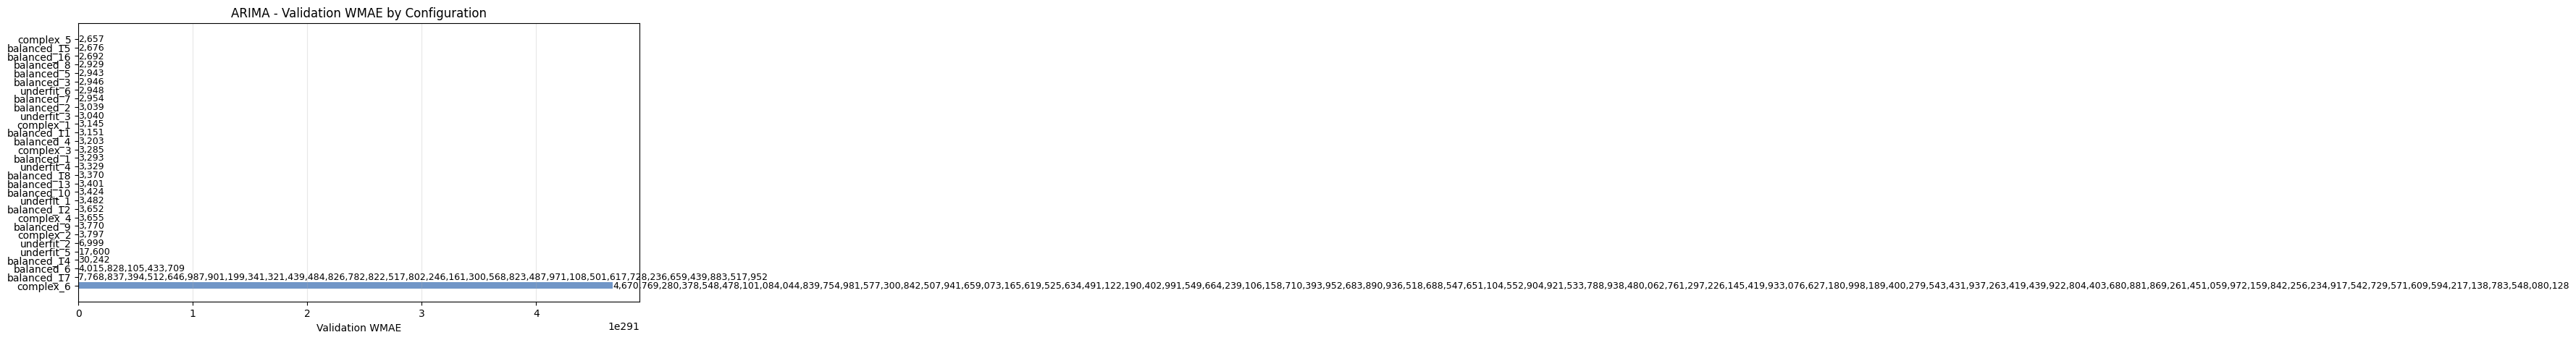

2026/07/12 02:25:27 INFO mlflow.tracking._tracking_service.client: 🏃 View run ARIMA_complex_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/1/runs/f78cd930dbb74f63b5545cd0f35ca801.
2026/07/12 02:25:27 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/1.
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import

In [12]:
os.makedirs("Plots", exist_ok=True)

top_runs = results_df.sort_values("val_wmae").copy()
colors = top_runs["label"].map(lambda label: GREEN if label == best_label else BLUE)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_runs["label"], top_runs["val_wmae"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Validation WMAE")
ax.set_title("ARIMA - Validation WMAE by Configuration")
ax.grid(axis="x", alpha=0.3)

for idx, value in enumerate(top_runs["val_wmae"]):
    ax.text(value + 25, idx, f"{value:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plot_path = "Plots/arima_wmae_comparison.png"
plt.savefig(plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(plot_path)

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="ARIMA_Analysis",
    group="ARIMA",
    job_type="analysis",
    tags=["ARIMA", "analysis", "validation_wmae"],
    reinit=True,
)

wandb.log({
    "arima_wmae_comparison": wandb.Image(plot_path),
    "best_val_wmae": best_val_wmae,
})

wandb.finish()


### 13. Error Analysis
    

In [13]:
best_cv_df = cv_by_label[best_label].copy()
best_cv_df["abs_error"] = (best_cv_df["y"] - best_cv_df[MODEL_COL]).abs()
best_cv_df[["Store", "Dept"]] = best_cv_df["unique_id"].str.split("_", n=1, expand=True)

display(best_cv_df.head())

worst_store_dept = (
    best_cv_df
    .groupby(["Store", "Dept"])["abs_error"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

display(worst_store_dept)

holiday_error = best_cv_df.groupby("IsHoliday")["abs_error"].mean()
display(holiday_error)

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_metric("holiday_week_mae", float(holiday_error.get(True, np.nan)))
    mlflow.log_metric("nonholiday_week_mae", float(holiday_error.get(False, np.nan)))


,unique_id,ds,y,ARIMA,used_fallback,IsHoliday,abs_error,Store,Dept
0,10_1,2012-02-03,36444.00,40440.945033,False,False,3996.945033,10,1
1,10_1,2012-02-10,50434.11,44228.847911,False,True,6205.262089,10,1
2,10_1,2012-02-17,74930.33,42373.027391,False,False,32557.302609,10,1
3,10_1,2012-02-24,28751.57,38603.672456,False,False,9852.102456,10,1
4,10_1,2012-03-02,30525.88,36422.012487,False,False,5896.132487,10,1


Store  Dept
38     38      174092.885058
10     72       40437.473762
35     72       34526.786643
20     72       31376.905761
14     72       28814.230016
       92       26443.994095
27     72       24123.231502
2      16       22563.081216
10     7        21779.931579
18     72       21234.263540
23     72       20869.420601
22     72       20750.771156
14     95       19541.167554
       16       19167.309247
19     16       18086.203211
Name: abs_error, dtype: float64

IsHoliday
False    2602.477418
True     2859.115248
Name: abs_error, dtype: float64

2026/07/12 02:25:42 INFO mlflow.tracking._tracking_service.client: 🏃 View run ARIMA_complex_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/1/runs/f78cd930dbb74f63b5545cd0f35ca801.
2026/07/12 02:25:42 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/1.


### 14. Error Plots
    

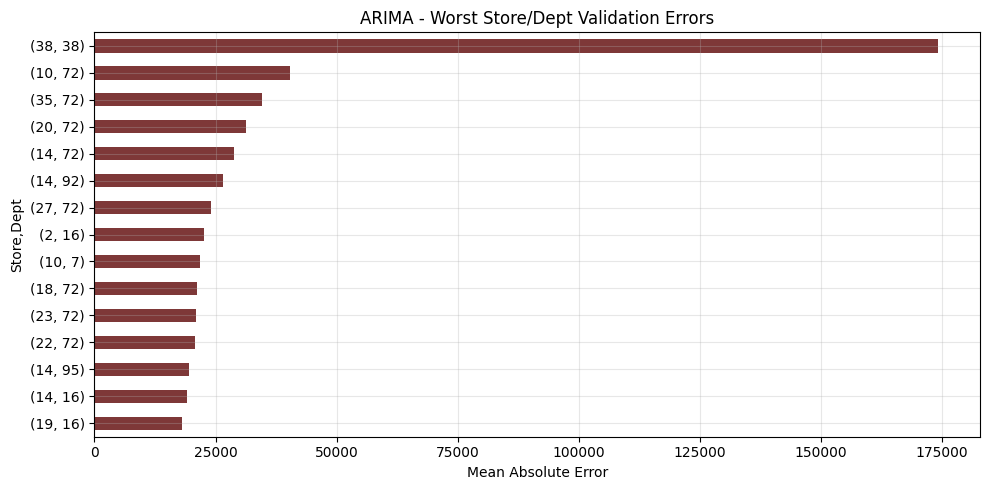

2026/07/12 02:25:50 INFO mlflow.tracking._tracking_service.client: 🏃 View run ARIMA_complex_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/1/runs/f78cd930dbb74f63b5545cd0f35ca801.
2026/07/12 02:25:50 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/1.
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

worst_store_dept.sort_values().plot(
    kind="barh",
    ax=ax,
    color=RED,
)

ax.set_xlabel("Mean Absolute Error")
ax.set_title("ARIMA - Worst Store/Dept Validation Errors")
ax.grid(True, alpha=0.3)

plt.tight_layout()
error_plot_path = "Plots/arima_worst_store_dept.png"
plt.savefig(error_plot_path, dpi=200)
plt.show()

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_artifact(error_plot_path)

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="ARIMA_Error_Analysis",
    group="ARIMA",
    job_type="analysis",
    tags=["ARIMA", "error_analysis"],
    reinit=True,
)

wandb.log({
    "arima_worst_store_dept": wandb.Image(error_plot_path),
    "holiday_week_mae": float(holiday_error.get(True, np.nan)),
    "nonholiday_week_mae": float(holiday_error.get(False, np.nan)),
})

wandb.finish()


### 15. Best Model
    

In [15]:
print("Best label:", best_label)
print("Best run id:", best_run_id)
print("Best validation WMAE:", best_val_wmae)

assert best_label is not None
assert best_run_id is not None

best_row = results_df[results_df["label"] == best_label].iloc[0]
best_config = next(config for config in param_grid if config["label"] == best_label)

print("Best config:")
display(best_config)

fallback_by_id = (
    long_df.sort_values("ds")
    .groupby("unique_id")["y"]
    .last()
    .astype(float)
    .to_dict()
)
global_fallback = float(long_df["y"].median())

print(f"Fallback values available for {len(fallback_by_id)} series")
print(f"Global fallback Weekly_Sales: {global_fallback:,.2f}")

final_models, final_failures = fit_arima_models(
    full_long_df=arima_df,
    ids=arima_ids,
    config=best_config,
)

print(f"Final ARIMA models fitted: {len(final_models):,}")
print(f"Final ARIMA failed series: {len(final_failures):,}")

os.makedirs("artifacts", exist_ok=True)
best_model_dir = Path("artifacts") / f"arima_final_{best_label}"
best_model_dir.mkdir(parents=True, exist_ok=True)
arima_model_path = best_model_dir / "arima_models.joblib"

joblib.dump(
    {
        "models": final_models,
        "best_config": best_config,
        "fallback_by_id": fallback_by_id,
        "global_fallback": global_fallback,
        "failed_series": final_failures,
    },
    arima_model_path,
)

print("Final ARIMA model artifact saved to:", arima_model_path)

pipeline_model = ARIMAForecastPipeline(
    fallback_by_id=fallback_by_id,
    global_fallback=global_fallback,
)

class _SignatureContext:
    artifacts = {"arima_model_path": str(arima_model_path)}

_temp = ARIMAForecastPipeline(
    fallback_by_id=fallback_by_id,
    global_fallback=global_fallback,
)
_temp.load_context(_SignatureContext())

sample_output = _temp.predict(_SignatureContext(), test_df)
signature = infer_signature(test_df, sample_output)

display(sample_output.head())

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_param("registered_model_name", "ARIMA_WalmartForecast")
    mlflow.log_metric("best_val_wmae", best_val_wmae)
    mlflow.log_metric("final_failed_series", len(final_failures))
    mlflow.log_param("best_label", best_label)
    mlflow.log_param("best_order", arima_order(best_config))
    mlflow.log_param("best_p", best_config["p"])
    mlflow.log_param("best_d", best_config["d"])
    mlflow.log_param("best_q", best_config["q"])
    mlflow.log_param("best_trend", best_config["trend"])
    mlflow.log_param("best_enforce_stationarity", best_config["enforce_stationarity"])
    mlflow.log_param("best_enforce_invertibility", best_config["enforce_invertibility"])
    mlflow.log_param("best_concentrate_scale", best_config["concentrate_scale"])
    mlflow.log_param("best_maxiter", best_config["maxiter"])
    mlflow.log_param("n_exog_cols", 0)
    mlflow.log_param("final_arima_n_series", len(arima_ids))
    mlflow.log_param("fallback_method", "last_observed_sales_by_store_dept")
    mlflow.log_metric("global_fallback_weekly_sales", global_fallback)
    mlflow.log_param("final_gradient_logging_applicable", False)

    logged_model_info = mlflow.pyfunc.log_model(
        artifact_path="pipeline",
        python_model=pipeline_model,
        artifacts={"arima_model_path": str(arima_model_path)},
        code_paths=[str(repo_root / "src")],
        signature=signature,
        input_example=test_df.head(20),
        registered_model_name="ARIMA_WalmartForecast",
    )

model_uri = logged_model_info.model_uri
print("Logged model URI:", model_uri)


Best label: complex_5
Best run id: f78cd930dbb74f63b5545cd0f35ca801
Best validation WMAE: 2657.0812118202366
Best config:


{'label': 'complex_5',
 'regime': 'complex',
 'p': 3,
 'd': 0,
 'q': 3,
 'trend': 'c',
 'enforce_stationarity': False,
 'enforce_invertibility': False,
 'concentrate_scale': False,
 'maxiter': 160}

Fallback values available for 3331 series
Global fallback Weekly_Sales: 7,612.03
Fit 250/2,660 final ARIMA models
Fit 500/2,660 final ARIMA models
Fit 750/2,660 final ARIMA models
Fit 1,000/2,660 final ARIMA models
Fit 1,250/2,660 final ARIMA models
Fit 1,500/2,660 final ARIMA models
Fit 1,750/2,660 final ARIMA models
Fit 2,000/2,660 final ARIMA models
Fit 2,250/2,660 final ARIMA models
Fit 2,500/2,660 final ARIMA models
Final ARIMA models fitted: 0
Final ARIMA failed series: 2,660
Final ARIMA model artifact saved to: artifacts/arima_final_complex_5/arima_models.joblib


/Users/macbookpro/Desktop/ml-final-project-walmart-recruiting/.venv311/lib/python3.11/site-packages/mlflow/types/utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


,Id,Weekly_Sales
0,10_1_2012-11-02,58409.83
1,10_1_2012-11-09,58409.83
2,10_1_2012-11-16,58409.83
3,10_1_2012-11-23,58409.83
4,10_1_2012-11-30,58409.83


/Users/macbookpro/Desktop/ml-final-project-walmart-recruiting/.venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Successfully registered model 'ARIMA_WalmartForecast'.
2026/07/12 02:28:59 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: ARIMA_WalmartForecast, version 1
Created version '1' of model 'ARIMA_WalmartForecast'.
2026/07/12 02:29:06 INFO mlflow.tracking._tracking_service.client: 🏃 View run ARIMA_complex_5 at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/1/runs/f78cd930dbb74f63b5545cd0f35ca801.
2026/07/12 02:29:06 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/dkhak22/ml-final-project-store-sales-forecasting.mlflow/#/experiments/

Logged model URI: runs:/f78cd930dbb74f63b5545cd0f35ca801/pipeline


### 16. Test Loading
    

In [16]:
loaded_model = mlflow.pyfunc.load_model(model_uri)
loaded_preds = loaded_model.predict(test_df.head(200))

display(loaded_preds.head())
print("Loaded prediction shape:", loaded_preds.shape)
assert set(loaded_preds.columns) == {"Id", "Weekly_Sales"}
assert loaded_preds["Weekly_Sales"].notna().all()


,Id,Weekly_Sales
0,1_1_2012-11-02,27390.81
1,1_1_2012-11-09,27390.81
2,1_1_2012-11-16,27390.81
3,1_1_2012-11-23,27390.81
4,1_1_2012-11-30,27390.81


Loaded prediction shape: (200, 2)
